# Semantic search experiment

CISI dataset, block-level search. I compare five variants:

- TF-IDF
- Sentence-BERT
- fallback hybrid
- weighted hybrid
- interleaving hybrid

CISI has almost no clean `full` overlap examples, so I add 80 short synthetic full-overlap queries. They are marked as `synthetic_full` in the tables.

In [1]:
import pandas as pd
from src.case_study.pipeline import run_pipeline

output = run_pipeline("data/processed", "artifacts")
summary = output["result"]

print(f"documents: {summary['n_documents']}")
print(f"blocks: {summary['n_blocks']}")
print(f"scored queries: {summary['n_queries']}")
print(f"synthetic full queries: {summary['n_synthetic_full_queries']}")
print(f"validation queries: {summary['n_val_queries']}")
print(f"test queries: {summary['n_test_queries']}")
print(f"best alpha: {summary['alpha']:.2f}")
print(f"fallback threshold: {summary['fallback_threshold']:.2f}")

documents: 1460
blocks: 1973
scored queries: 156
synthetic full queries: 80
validation queries: 39
test queries: 117
best alpha: 0.30
fallback threshold: 0.25


## Data

In [2]:
dataset_summary = pd.DataFrame(
    [
        ["documents", summary["n_documents"]],
        ["blocks", summary["n_blocks"]],
        ["original CISI queries with qrels", summary["n_original_scored_queries"]],
        ["synthetic full-overlap queries", summary["n_synthetic_scored_queries"]],
        ["validation queries", summary["n_val_queries"]],
        ["test queries", summary["n_test_queries"]],
    ],
    columns=["item", "count"],
)
dataset_summary

,item,count
0,documents,1460
1,blocks,1973
2,original CISI queries with qrels,76
3,synthetic full-overlap queries,80
4,validation queries,39
5,test queries,117


In [3]:
query_source_counts = (
    output["queries"]
    .assign(scored=output["queries"]["query_id"].isin(output["pairs"]["query_id"]))
    .groupby(["source", "scored"])
    .size()
    .reset_index(name="n_queries")
)
query_source_counts

,source,scored,n_queries
0,cisi,False,36
1,cisi,True,76
2,synthetic_full,True,80


In [4]:
pair_counts = pd.crosstab(
    output["pairs"]["overlap_group"],
    output["pairs"]["query_source"],
)
pair_counts

query_source,cisi,synthetic_full
overlap_group,,
full,2,80
none,410,0
partial,2702,0


## Overall metrics

Test split only. For normal score-based methods I aggregate block scores to documents by max score. For `hybrid_interleave` I alternate the TF-IDF and BERT ranked lists and skip duplicates.

In [5]:
overall = output["overall"].copy()
score_columns = ["block_mrr", "doc_mrr", "doc_hit@10"]
overall[score_columns] = overall[score_columns].round(4)
overall

,method,block_mrr,doc_mrr,doc_hit@10
0,hybrid_interleave,0.7957,0.8058,0.9744
1,bert,0.7590,0.7952,0.9487
2,hybrid_weighted,0.7811,0.7897,0.9573
3,tfidf,0.7720,0.7733,0.9231
4,hybrid_fallback,0.7720,0.7733,0.9231


## Difference from TF-IDF

In [6]:
baseline = output["overall"].set_index("method").loc["tfidf", score_columns]
delta_vs_tfidf = output["overall"].set_index("method")[score_columns].subtract(baseline)
delta_vs_tfidf.round(4)

,block_mrr,doc_mrr,doc_hit@10
method,,,
hybrid_interleave,0.0237,0.0325,0.0513
bert,-0.0131,0.0219,0.0256
hybrid_weighted,0.0091,0.0163,0.0342
tfidf,0.0000,0.0000,0.0000
hybrid_fallback,0.0000,0.0000,0.0000


## Overlap buckets

This table is pair-level: one row in the calculation is one relevant `(query, doc)` pair.

In [7]:
by_group = output["by_group"].copy()
by_group[score_columns] = by_group[score_columns].round(4)
by_group

,overlap_group,n_pairs,n_queries,method,block_mrr,doc_mrr,doc_hit@10
0,full,62,62,tfidf,0.9593,0.9593,1.0000
1,full,62,62,hybrid_fallback,0.9593,0.9593,1.0000
2,full,62,62,hybrid_weighted,0.9562,0.9562,0.9839
3,full,62,62,hybrid_interleave,0.9534,0.9534,0.9839
4,full,62,62,bert,0.8283,0.8329,0.9677
5,none,318,36,bert,0.0196,0.0209,0.0278
6,none,318,36,hybrid_interleave,0.0111,0.0119,0.0000
7,none,318,36,hybrid_weighted,0.0066,0.0073,0.0000
8,none,318,36,tfidf,0.0010,0.0012,0.0000
9,none,318,36,hybrid_fallback,0.0010,0.0012,0.0000


In [8]:
doc_mrr_pivot = by_group.pivot(
    index="overlap_group",
    columns="method",
    values="doc_mrr",
)
doc_mrr_pivot

method,bert,hybrid_fallback,hybrid_interleave,hybrid_weighted,tfidf
overlap_group,,,,,
full,0.8329,0.9593,0.9534,0.9562,0.9593
none,0.0209,0.0012,0.0119,0.0073,0.0012
partial,0.7285,0.5523,0.6218,0.5858,0.5523


## MRR plot

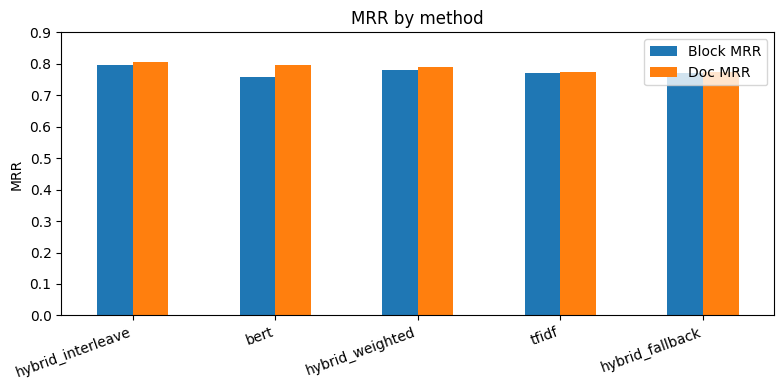

In [9]:
import matplotlib.pyplot as plt

plot_data = output["overall"].set_index("method")[["block_mrr", "doc_mrr"]]
ax = plot_data.plot(kind="bar", figsize=(8, 4), ylim=(0, 0.9))
ax.set_title("MRR by method")
ax.set_ylabel("MRR")
ax.set_xlabel("")
ax.legend(["Block MRR", "Doc MRR"])
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

## Notes

- `full`: TF-IDF is best.
- `partial` and `none`: BERT is stronger.
- `hybrid_interleave` gives the best doc MRR in the final table.
- BERT gives the best hit@10.